In [1]:
#Kaggleの『AI Learner Tech: EV Prices 2026 (EDA & ML)』
#(https://www.kaggle.com/datasets/ailearner-researchlab/ai-learner-tech-ev-prices-and-specs-2026?select=AI_Learner_EV_Dataset_Pro.csv)
#を使用して欧州で販売されるEV車のコスパTop 10と割高Top 10モデルを予測した。

# =========================
# ① ライブラリ読み込み
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

# =========================
# ② csvデータ読み込み
# =========================
dir_path = '/content/drive/MyDrive/datascience-for-beginner/archive_EV/'
df = pd.read_csv(dir_path + 'AI_Learner_EV_Dataset_Pro.csv')


In [2]:
# =========================
# ③ 外れ値除去（IQR）
# =========================
cols = ["PriceEuro", "TopSpeed_KmH", "Range_Km", "AccelSec"]  #対象の列を指定

def remove_outliers_iqr(df, cols):  #DataFrame（df）と対象列（cols）を受け取る関数を定義
    df_clean = df.copy()  #元データを壊さないためコピーを作成
    for col in cols:
        #四分位数を計算
        Q1 = df_clean[col].quantile(0.25) #Q1（第1四分位数）：小さい順に並べたときの下から25%の位置
        Q3 = df_clean[col].quantile(0.75) #Q3（第3四分位数）：下から75%の位置
        IQR = Q3 - Q1 #IQRを計算
        #外れ値の範囲を決定:この範囲を外れると「外れ値」と認定
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        #外れ値を削除:下限以上、上限以下
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean #最終結果を返す

df = remove_outliers_iqr(df, cols)

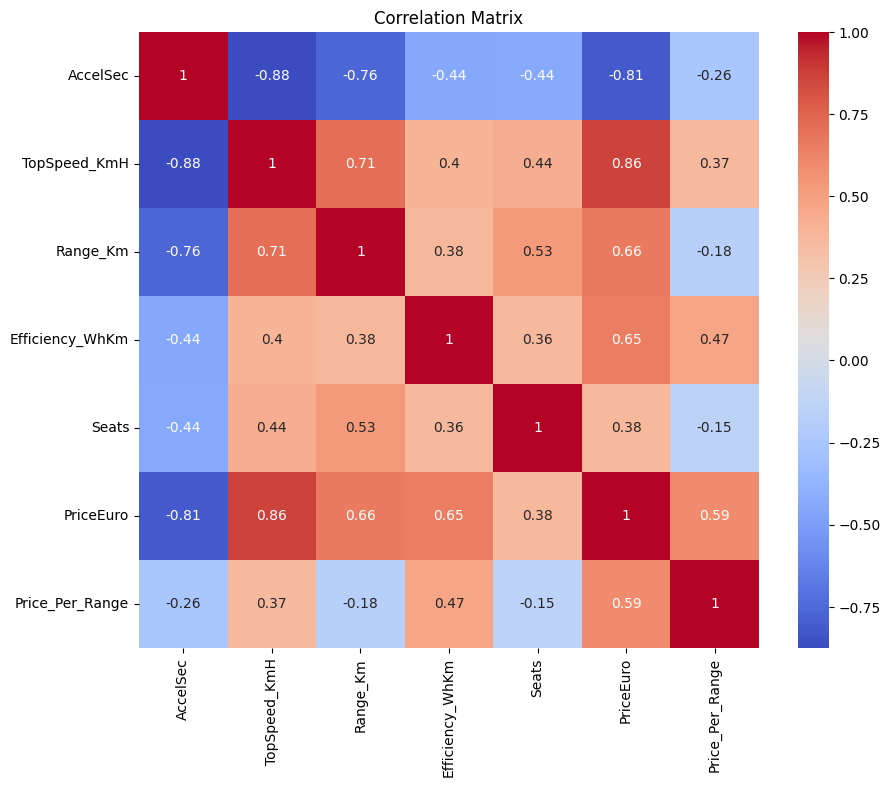

In [3]:
# =========================
# ④ 可視化（相関関係確認）
#Heatmapの表示結果からはAccelSec, TopSpeed_KmHとPriceEuroの相関性が高いように見える
# =========================
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [4]:
# =========================
# ⑤ 特徴量エンジニアリング
#欧州消費者がEV車に求めるものとしては走行距離や効率性が高いと思わるため
#Perfomance_IndexとEfficiency_Scoreとして下記条件を設定
# =========================
# ① Brandを保存
df["Brand_original"] = df["Brand"]

# ② OneHot
df = pd.get_dummies(df, columns=["Brand"], drop_first=True)

# ③ その他特徴量
df["Efficiency_Score"] = 1 / df["Efficiency_WhKm"]

In [5]:
# ===== 特徴量 =====
df["Performance_Index"] = df["Range_Km"] / df["AccelSec"]
df["Efficiency_Score"] = 1 / df["Efficiency_WhKm"]

# ===== 目的変数 =====
y = df["PriceEuro"]

# ===== 特徴量セット =====
# Brand列を取得
brand_cols = [col for col in df.columns if col.startswith("Brand_") and df[col].dtype != "object"]

features = [
    "Range_Km",
    "TopSpeed_KmH",
    "AccelSec",
    "Efficiency_WhKm",
    "Performance_Index",
    "Efficiency_Score"
] + brand_cols

X = df[features]
y = df["PriceEuro"]  # ← logやめる（まずは）

# ===== 分割 =====
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# ===== 学習 =====
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# ===== 予測 =====
pred = model.predict(X_valid)

rmse = np.sqrt(mean_squared_error(y_valid, pred))
print("RMSE:", rmse)

RMSE: 4529.056255955093


In [6]:
#AIで「欧州消費者がEV車に求めるもの」と検索すると1回の充電で走行できる総距離距離、キロあたりの効率性、価格などとなっているので
#以下の項目をPopularity_scoreとして重み付けをした。但し価格と性能は比例すると推測されるので価格の重み付けは10%とした。：

df["Popularity_Score"] = (
    0.40 * (df["Range_Km"] / df["Range_Km"].max()) +     # 航続距離 40%
    0.30 * (df["Efficiency_WhKm"].min() / df["Efficiency_WhKm"]) +  # 電力の効率性 30%
    0.20 * (df["Price_Per_Range"].min() / df["Price_Per_Range"]) +  # キロ当たりの効率性 20%
    0.10 * (1 / np.log1p(df["PriceEuro"]))  # 価格 10%
)

In [7]:
# =========================
# ⑦ 特徴量選択
# =========================

#モデルに入力する説明変数（X）を定義
features = [
    "Range_Km",
    "TopSpeed_KmH",
    "AccelSec",
    "Efficiency_WhKm",
    "Performance_Index",
    "Efficiency_Score"
] + brand_cols

X = df[features]  #入力データ（X）
y = np.log1p(df["PriceEuro"]) #目的変数（y）

In [8]:
# =========================
# ⑧ 標準化（SVR用）
# =========================
#SVR（サポートベクター回帰）用にデータのスケールを揃える処理
#できるだけ誤差を小さくしつつ、シンプルな関数で予測する回帰モデル
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  #fit（学習）:各列の平均と標準偏差を計算 + transform（変換）:スケール変換

In [9]:
# =========================
# ⑨ モデル定義
# =========================

#どのモデルで学習するかをまとめて定義して比較
models = {
    "Ridge": Ridge(alpha=1.0),  #Ridge（リッジ回帰）複雑になりすぎないよう制限
    "SVR": SVR(kernel="rbf", C=10), #サポートベクター回帰（Support Vector Regression）
    "LightGBM": LGBMRegressor(  #LightGBM
        n_estimators=100, #「木」の数
        max_depth=3,  #木の深さ
        learning_rate=0.05  #学習の慎重さ
    )
}

In [10]:
# =========================
# ⑩ CV(Cross Validation)評価
# =========================

#3つのモデル（Ridge / SVR / LightGBM）のうち一番適したモデルを順番に評価
print("=== Cross Validation ===")
for name, model in models.items():

    if name == "SVR":
        scores = cross_val_score(model, X_scaled, y,  #クロスバリデーションでモデルを評価
                                 cv=5,  #Cross Validation=5回テストして平均を取る
                                 scoring="neg_root_mean_squared_error") #RMSE:予測のズレの大きさ
    else:
        scores = cross_val_score(model, X, y,
                                 cv=5,
                                 scoring="neg_root_mean_squared_error")

    print(f"{name} RMSE:", -scores.mean())

=== Cross Validation ===
Ridge RMSE: 0.10960204020518527
SVR RMSE: 0.18809848843404015
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000909 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 123
[LightGBM] [Info] Number of data points in the train set: 73, number of used features: 6
[LightGBM] [Info] Start training from score 10.670894
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [11]:
# =========================
# ⑪ 最終モデル（Ridge）
# =========================

#CV評価の結果LightGBM RMSE: 0.18930778343589816, Ridge RMSE: 0.10960204020518527 SVR RMSE: 0.18809848843404015
#のためRMSEが一番低いRidgeがベストなモデルと判定

#データを 学習用80% / 検証用20% に分ける
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

model = Ridge(alpha=1.0)
model.fit(X_train, y_train) #特徴量 → 価格（log） の関係を学習

pred = model.predict(X_valid)

rmse = np.sqrt(mean_squared_error(y_valid, pred))

print("\nFinal RMSE:", rmse)


Final RMSE: 0.08951949410307583


In [12]:
# =========================
# ⑫ 全データで価格予測
# =========================
df["PredictedPrice"] = np.expm1(model.predict(X))

In [13]:
# =========================
# ⑬ コスパ指標
# =========================
df["Value_Score"] = df["Popularity_Score"] / df["PredictedPrice"]

In [14]:
# =========================
# ⑭ 結果表示
# =========================

# ① Residual(残差)を作る：「実際の価格 − モデルが予測した価格」 実際 < 予測 => 割安（コスパ良い）
df["Residual"] = df["PriceEuro"] - df["PredictedPrice"]

result = df[[
    "Brand_original",
    "Model",
    "PriceEuro",
    "PredictedPrice",
    "Range_Km",
    "Price_Per_Range",
    "Residual"   # 残差
]].sort_values("Residual")

print("\n=== コスパ最強 TOP10（割安） ===")
print(result.head(10))

print("\n=== 割高ワースト10 ===")
print(result.tail(10))

# =========================
# Residual分析
# =========================

print("\n=== Residual(「実際の価格 − モデルが予測した価格」の差)が大きい（割高側）TOP10 ===")
print(df.sort_values("Residual", ascending=False).head(10))

print("\n=== Residual(「実際の価格 − モデルが予測した価格」の差)が小さい（割安側）TOP10 ===")
print(df.sort_values("Residual", ascending=True).head(10))


=== コスパ最強 TOP10（割安） ===
   Brand_original                            Model  PriceEuro  PredictedPrice  \
1          Tesla             Cybertruck Dual Motor      55000    69518.062759   
28      Mercedes                              EQA       45000    57991.662191   
94         Tesla           Cybertruck Single Motor      45000    56942.491149   
6           Audi               e-tron S 55 quattro      93800    99014.419800   
20        Nissan               Ariya e-4ORCE 63kWh      50000    55123.834226   
10            MG                             ZS EV      30000    35028.213864   
92        Nissan               Ariya e-4ORCE 87kWh      57500    62505.014701   
32        Nissan   Ariya e-4ORCE 87kWh Performance      65000    69797.234323   
52           BMW                               i4       65000    69510.937940   
96          Opel                          Corsa-e       29146    33502.100147   

    Range_Km  Price_Per_Range      Residual  
1        460           119.57 -14518.

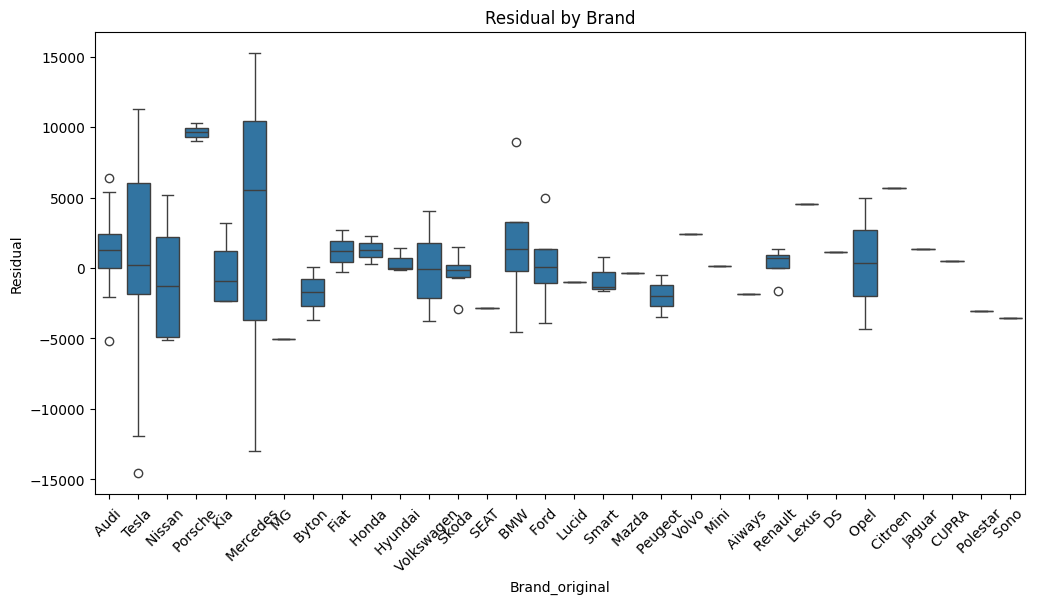

In [15]:
#結果の可視化①：Residual × ブランド　[ブランドごとのResidual]

plt.figure(figsize=(12,6))
sns.boxplot(x="Brand_original", y="Residual", data=df)

plt.xticks(rotation=45)
plt.title("Residual by Brand")
plt.show()

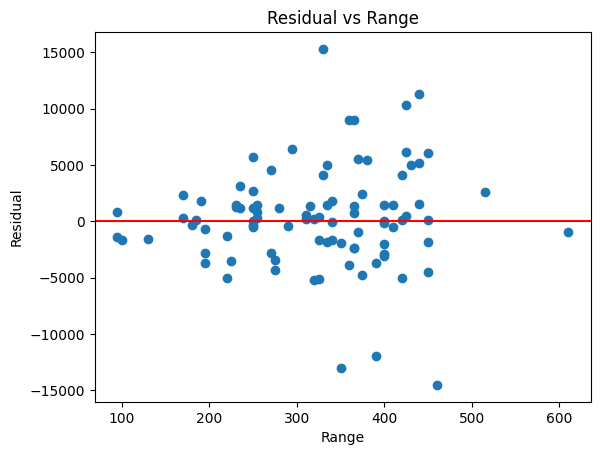

In [16]:
#結果の可視化②:Residual X Range　[Residualと走行距離]

plt.scatter(df["Range_Km"], df["Residual"])
plt.axhline(0, color='red')

plt.xlabel("Range")
plt.ylabel("Residual")
plt.title("Residual vs Range")
plt.show()

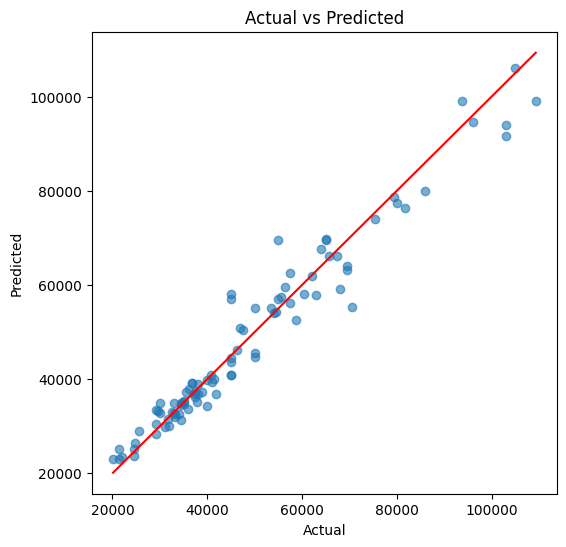

In [17]:
#結果の可視化③:Actual vs Predicted　[実際と予測]

plt.figure(figsize=(6,6))
plt.scatter(df["PriceEuro"], df["PredictedPrice"], alpha=0.6)

plt.plot(
    [df["PriceEuro"].min(), df["PriceEuro"].max()],
    [df["PriceEuro"].min(), df["PriceEuro"].max()],
    color='red'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()